# Лабораторная работа №7: Анализ и прогнозирование временного ряда

## Цель работы
Изучение основных методов анализа и прогнозирования временных рядов. В ходе работы мы выполним визуальный анализ данных, построим несколько прогнозных моделей и сравним их качество.

## Используемый датасет
В качестве данных используется временной ряд цен закрытия (`close_USD`) криптовалюты **Dash** (файл `dc.csv`). Данные представлены в дневном разрезе.

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot
import matplotlib.pyplot as plt

## 1. Загрузка данных
Загружаем данные из файла `dc.csv`. Используем первый столбец (`Date`) в качестве индекса с парсингом дат. Для анализа берем столбец `close_USD` (цена закрытия).

In [ ]:
fb1 = pd.read_csv('dc.csv',
                  index_col=0,
                  parse_dates=[0],  # Явно указываем, что первая колонка - даты
                  #names=['Date', 'Value'], # <-- Задаем имена сразу
                  usecols=[0, 8])

fb1 = fb1.sort_index() 

## 2. Первичный анализ и визуализация временного ряда

На этом этапе мы визуализируем временной ряд целиком и его первые 20 точек, чтобы оценить общую динамику и структуру данных.

### Визуализация ряда и первых точек

In [ ]:
fb1.head()

,close_USD
2018-05-07,9365.00
2018-05-08,9187.56
2018-05-09,9310.00
2018-05-10,9002.20
2018-05-11,8400.00


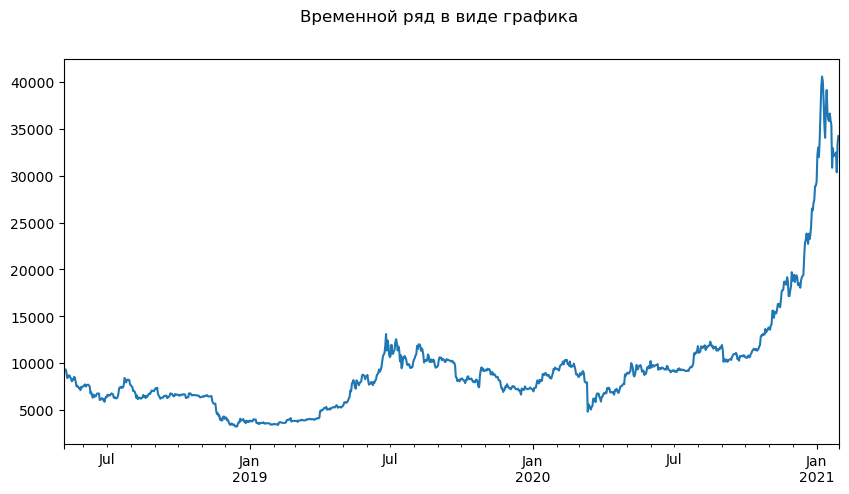

In [ ]:
fig, ax = pyplot.subplots(1, 1, figsize=(10, 5))
fig.suptitle('Временной ряд в виде графика')
fb1.plot(ax=ax, legend=False) # Pandas сам подставит даты из индекса на ось X
pyplot.show()

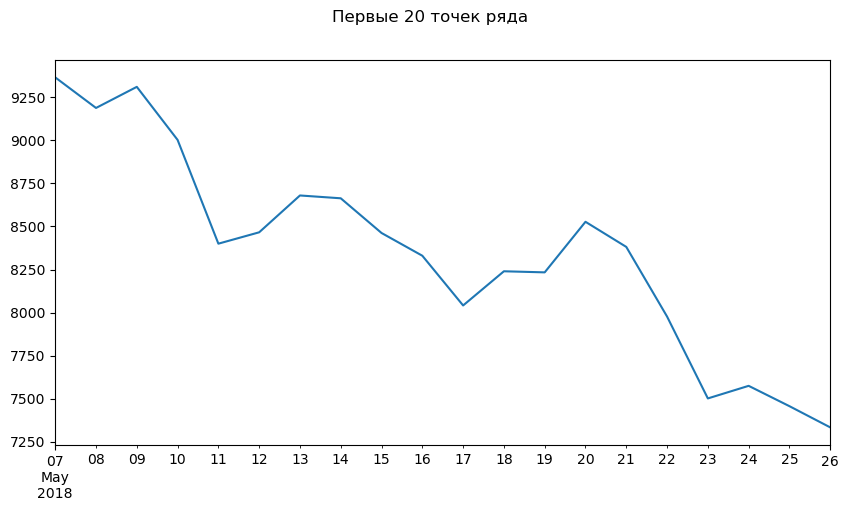

In [ ]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Первые 20 точек ряда')
fb1[:20].plot(ax=ax, legend=False)
pyplot.show()

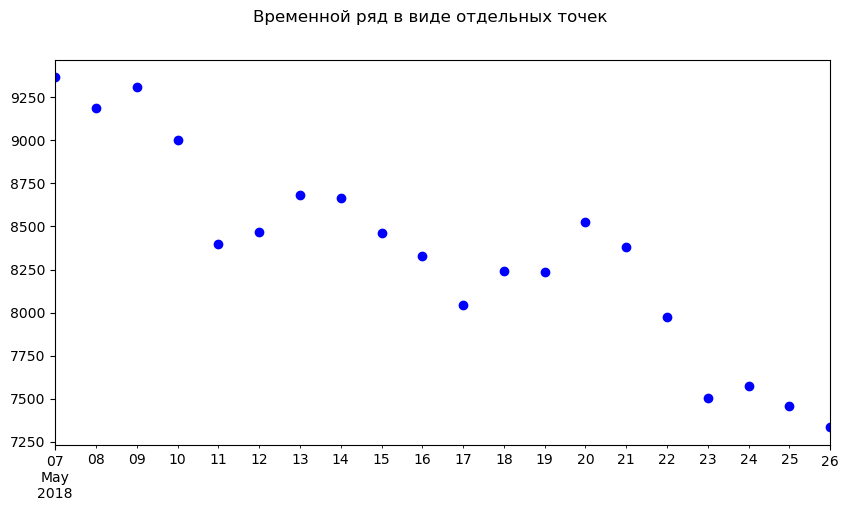

In [ ]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Временной ряд в виде отдельных точек')
fb1[:20].plot(ax=ax, legend=False, style='bo')
pyplot.show()

### Анализ распределения и зависимостей
Для понимания свойств ряда строятся вспомогательные графики:
- **Гистограмма:** показывает распределение цен.
- **График плотности:** сглаженная версия распределения.
- **Диаграмма рассеяния (Lag plots):** визуализирует зависимость между текущим значением и значением со сдвигом (лагом). Это помогает оценить наличие автокорреляции.
- **Коррелограмма (ACF):** показывает силу автокорреляции на разных лагах.

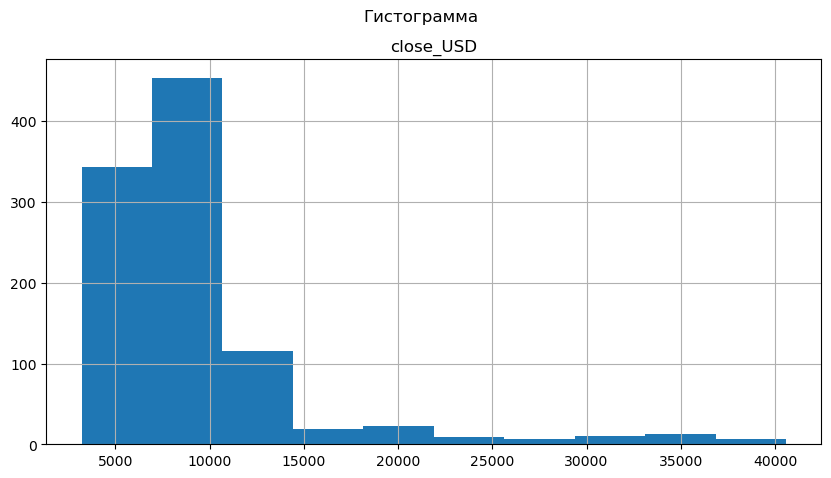

In [ ]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Гистограмма')
fb1.hist(ax=ax, legend=False)
pyplot.show()

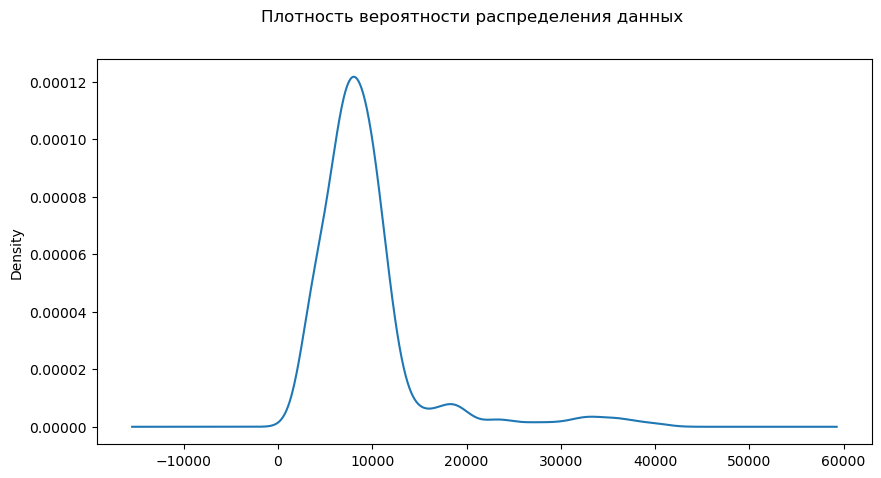

In [ ]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Плотность вероятности распределения данных')
fb1.plot(ax=ax, kind='kde', legend=False)
pyplot.show()

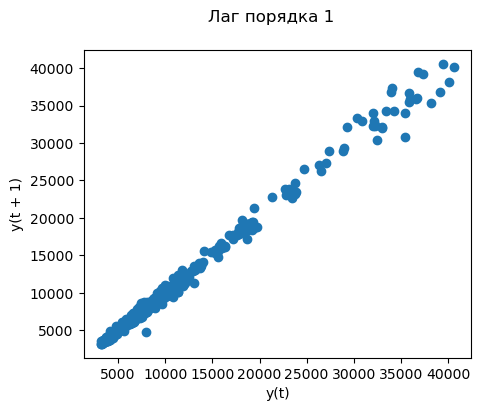

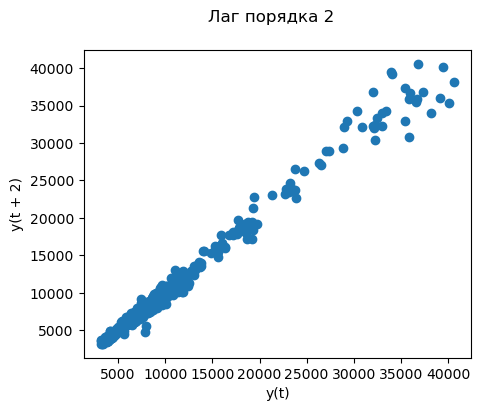

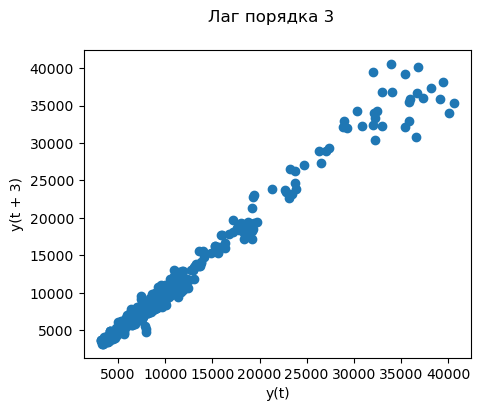

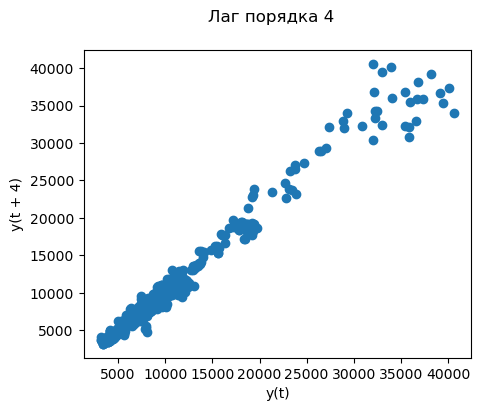

In [ ]:
for i in range(1, 5):
    fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(5,4))
    fig.suptitle(f'Лаг порядка {i}')
    pd.plotting.lag_plot(fb1, lag=i, ax=ax)
    pyplot.show()

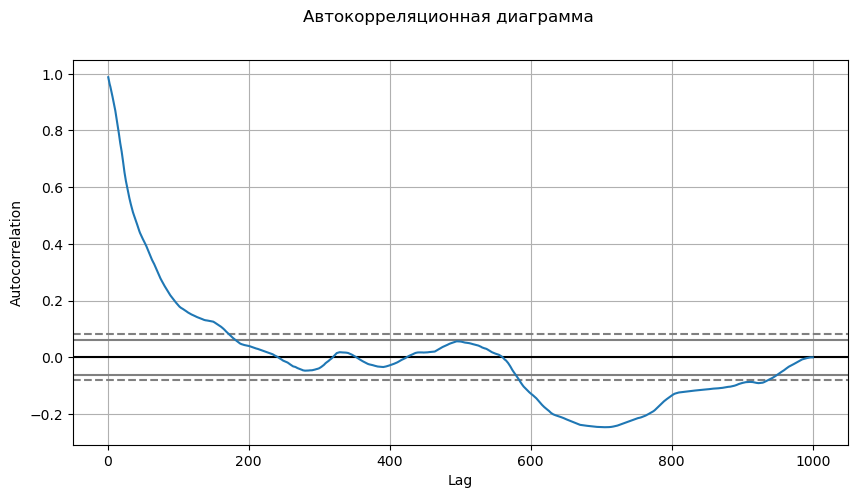

In [ ]:
# По оси Y откладывается ковариация 
# https://stats.stackexchange.com/questions/357300/what-does-pandas-autocorrelation-graph-show
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Автокорреляционная диаграмма')
pd.plotting.autocorrelation_plot(fb1, ax=ax)
pyplot.show()

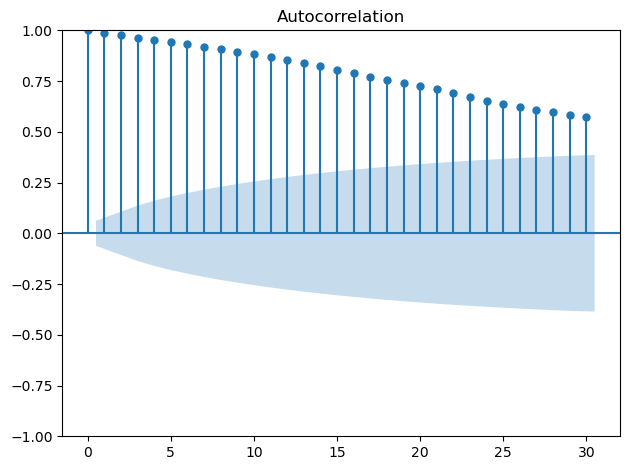

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(fb1, lags=30)
plt.tight_layout()

## 3. Декомпозиция временного ряда
Для выявления тренда, сезонности и остатков применяется аддитивная модель декомпозиции (`seasonal_decompose`). Это помогает понять, из каких компонентов состоит наш ряд.

In [ ]:
# https://www.statsmodels.org/dev/generated/statsmodels.tsa.seasonal.seasonal_decompose.html
from statsmodels.tsa.seasonal import seasonal_decompose
# Аддитивная модель
def plot_decompose(data=fb1['close_USD'], model='add'):
    result_add = seasonal_decompose(data, model = 'add')
    fig = result_add.plot()
    fig.set_size_inches((10, 8))
    # Перерисовка
    fig.tight_layout()
    plt.show()

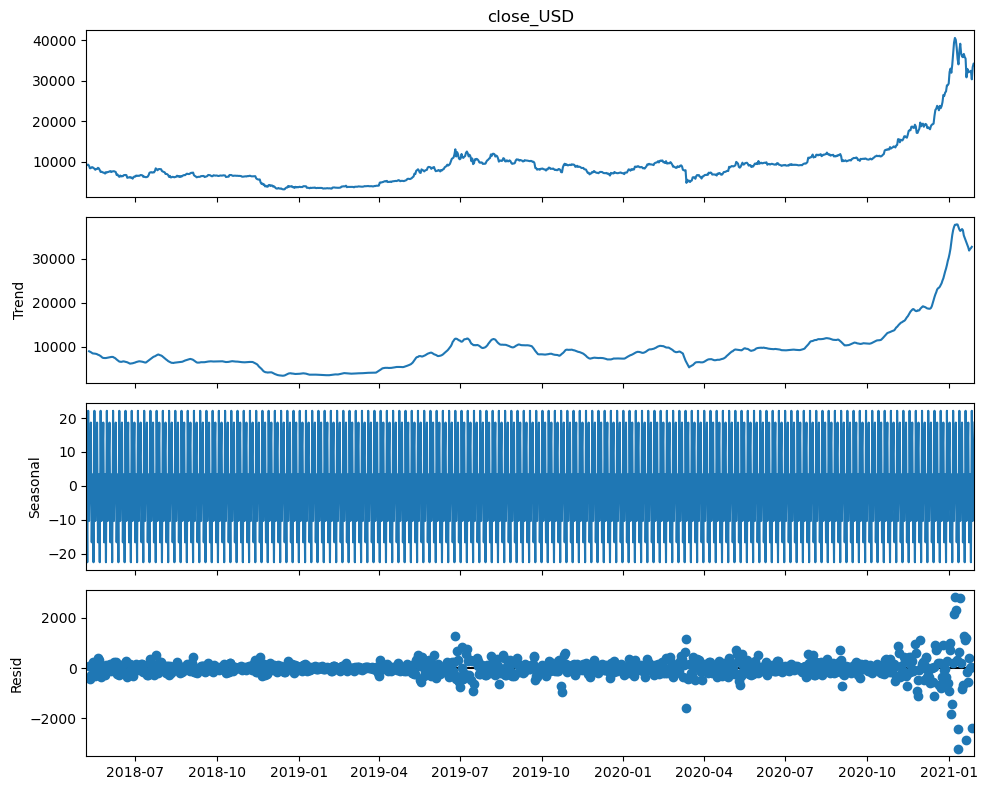

In [ ]:
plot_decompose(data=fb1['close_USD'], model='add')

In [ ]:
ts_fb2 = fb1.copy()

## 4. Скользящие средние
Строятся простые скользящие средние (SMA) с окнами 10 и 20 дней. Это позволяет сгладить краткосрочные колебания и визуально оценить тренд.

In [ ]:
# Простое скользящее среднее (SMA)
ts_fb2['SMA_10'] = ts_fb2['close_USD'].rolling(10, min_periods=1).mean()
ts_fb2['SMA_20'] = ts_fb2['close_USD'].rolling(20, min_periods=1).mean()

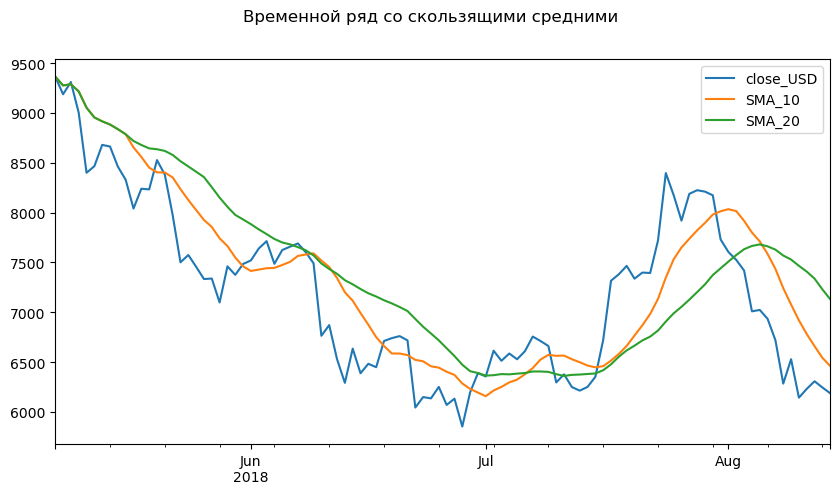

In [ ]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Временной ряд со скользящими средними')
ts_fb2[:100].plot(ax=ax, legend=True)
pyplot.show()

In [ ]:
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

## 5. Подготовка данных и разделение на выборки
Для построения прогнозных моделей выполняется разделение данных:
- **Обучающая выборка:** первые 80% наблюдений.
- **Тестовая выборка:** последние 20% наблюдений.
Временной индекс преобразуется в числовой (`xnum`) для использования в моделях, которым требуются числовые признаки (например, символьная регрессия).

In [ ]:
# Целочисленная метка шкалы времени 
xnum = list(range(ts_fb2.shape[0]))
# Разделение выборки на обучающую и тестовую
Y = ts_fb2['close_USD'].values
train_size = int(len(Y) * 0.8)
xnum_train, xnum_test = xnum[0:train_size], xnum[train_size:]
train, test = Y[0:train_size], Y[train_size:]
history_arima = [x for x in train]
history_es = [x for x in train]

## 6. Прогнозирование временного ряда

В работе используются три различных подхода к прогнозированию.

### Авторегрессионная модель (ARIMA)
ARIMA (AutoRegressive Integrated Moving Average) — классический статистический метод для прогнозирования временных рядов. Модель описывается параметрами (p,d,q), где `p` — порядок авторегрессии, `d` — порядок дифференцирования, `q` — порядок скользящего среднего. В работе используется модель с параметрами `(6, 1, 0)`.

**Метод:** Рекурсивное прогнозирование (one-step-ahead forecast) на каждом шаге тестовой выборки с переобучением модели на расширяющемся окне данных (`history`).

In [ ]:
# Параметры модели (p,d,q) 
arima_order = (6,1,0)
# Формирование предсказаний
predictions_arima = list()
for t in range(len(test)):
    model_arima = ARIMA(history_arima, order=arima_order)
    model_arima_fit = model_arima.fit()
    yhat_arima = model_arima_fit.forecast()[0]
    predictions_arima.append(yhat_arima)
    history_arima.append(test[t])
# Вычисление метрики RMSE
error_arima = mean_squared_error(test, predictions_arima)

### Экспоненциальное сглаживание (Holt-Winters)
Экспоненциальное сглаживание — еще один статистический метод, который хорошо работает для рядов с трендом и сезонностью (хотя в данной реализации используется простая версия).

**Метод:** Прогнозирование также выполняется рекурсивно на расширяющемся окне данных.

In [ ]:
# Формирование предсказаний
predictions_es = list()
for t in range(len(test)):
    model_es = ExponentialSmoothing(history_es)
    model_es_fit = model_es.fit()
    yhat_es = model_es_fit.forecast()[0]
    predictions_es.append(yhat_es)
    history_es.append(test[t])
# Вычисление метрики RMSE
error_es = mean_squared_error(test, predictions_es)

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [ ]:
# Ошибка прогноза
np.mean(Y), error_arima, error_es

(9310.33585, 763746.8787530363, 740568.0693833422)

In [ ]:
# Записываем предсказания в DataFrame
ts_fb2['predictions_ARIMA'] = (train_size * [np.NAN]) + list(predictions_arima)
ts_fb2['predictions_HWES'] = (train_size * [np.NAN]) + list(predictions_es)

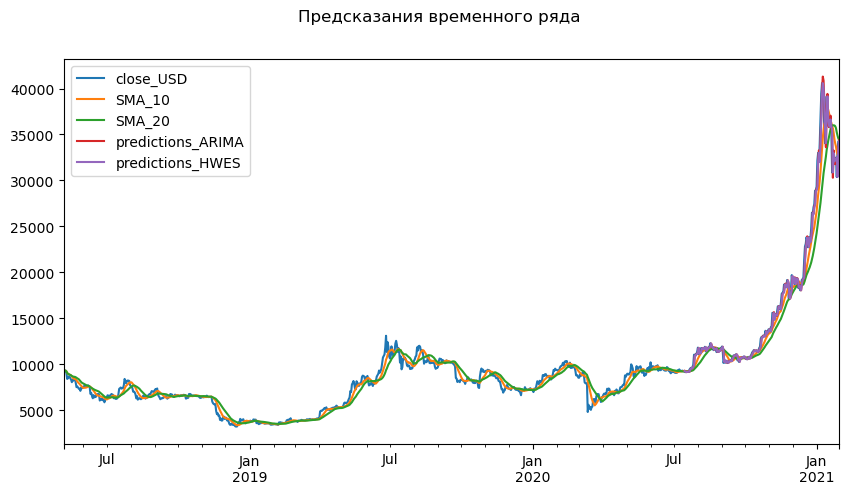

In [ ]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Предсказания временного ряда')
ts_fb2.plot(ax=ax, legend=True)
pyplot.show()

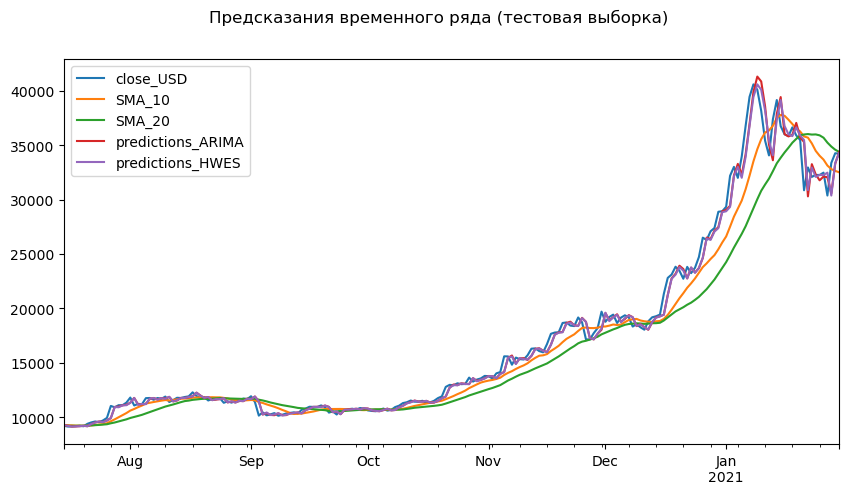

In [ ]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Предсказания временного ряда (тестовая выборка)')
ts_fb2[train_size:].plot(ax=ax, legend=True)
pyplot.show()

### Символьная регрессия (GPlearn)
Символьная регрессия использует генетическое программирование для поиска математической формулы, которая наилучшим образом описывает зависимость целевой переменной (`close_USD`) от времени (`X0`).

**Параметры модели:**
- `population_size`: 500
- `generations`: 70
- `function_set`: `['add', 'sub', 'mul', 'div', 'sin']`
- `metric`: `'mse'` (среднеквадратичная ошибка)
- `const_range`: `(-100, 100)`

**Визуализация:** Для наглядности построено дерево найденной модели, которое отражает структуру полученной формулы.

In [ ]:
#Прогнозирование временного ряда методом символьной регресии
from gplearn.genetic import SymbolicRegressor

In [ ]:
function_set = ['add', 'sub', 'mul', 'div', 'sin']
est_gp = SymbolicRegressor(population_size=500, metric='mse',
                               generations=70, stopping_criteria=0.01,
                               init_depth=(4, 10), verbose=1, function_set=function_set,
                               const_range=(-100, 100), random_state=0)

In [ ]:
est_gp.fit(np.array(xnum_train).reshape(-1, 1), train.reshape(-1, 1))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0   263.65      2.84484e+66       99      1.50571e+07              N/A      1.47m
   1   145.66      2.16035e+17       99      9.33651e+06              N/A     31.94s
   2    96.49      8.85155e+14      185      5.64073e+06              N/A     23.94s
   3   102.08      2.80265e+11       56       4.9409e+06              N/A     25.52s
   4   151.36      1.18202e+14      108      4.31084e+06              N/A     30.69s
   5   120.66      1.11437e+15      146      3.83451e+06              N/A     28.62s
   6   129.32      1.28149e+13      145      3.77756e+06              N/A     26.42s
   7   129.26      1.05721e+13      255      3.77184e+06              N/A     27.05s
   8   141.94      2.61487e+13      167      3.63572e+06              N/A  

,population_size,500
,generations,70
,tournament_size,20
,stopping_criteria,0.01
,const_range,"(-100, ...)"
,init_depth,"(4, ...)"
,init_method,'half and half'
,function_set,"['add', 'sub', ...]"
,metric,'mse'
,parsimony_coefficient,0.001
,p_crossover,0.9


In [ ]:
print(est_gp._program)

add(add(sub(sub(X0, sub(mul(42.876, -97.063), sub(X0, -86.349))), sub(div(X0, X0), add(sub(add(sub(sin(sub(-82.062, X0)), sub(div(X0, X0), div(35.484, -3.693))), -3.693), sub(div(X0, X0), div(35.484, -3.693))), div(35.484, -3.693)))), add(add(sub(add(29.736, X0), div(X0, X0)), sub(mul(sub(26.428, 26.637), mul(-91.195, 51.329)), sub(sin(add(sub(add(sub(sin(div(X0, X0)), sub(div(X0, X0), div(35.484, -3.693))), sub(26.428, 26.637)), sub(sin(-94.779), mul(sub(26.428, 26.637), mul(-91.195, 51.329)))), mul(42.876, -97.063))), mul(sin(sin(div(35.484, -3.693))), add(mul(add(X0, -50.392), sub(div(98.291, 57.146), div(35.484, -3.693))), mul(sub(X0, 12.024), mul(add(sub(sub(add(sub(sub(sub(add(sub(sub(add(sub(sin(sub(-82.062, X0)), sub(div(X0, X0), div(35.484, -3.693))), -3.693), sub(div(X0, sub(add(sub(sin(div(35.484, -3.693)), sub(sub(div(98.291, 57.146), div(-69.879, 32.655)), div(35.484, -3.693))), -3.693), sub(div(X0, X0), div(35.484, -3.693)))), div(35.484, -3.693))), sub(div(X0, X0), div(3

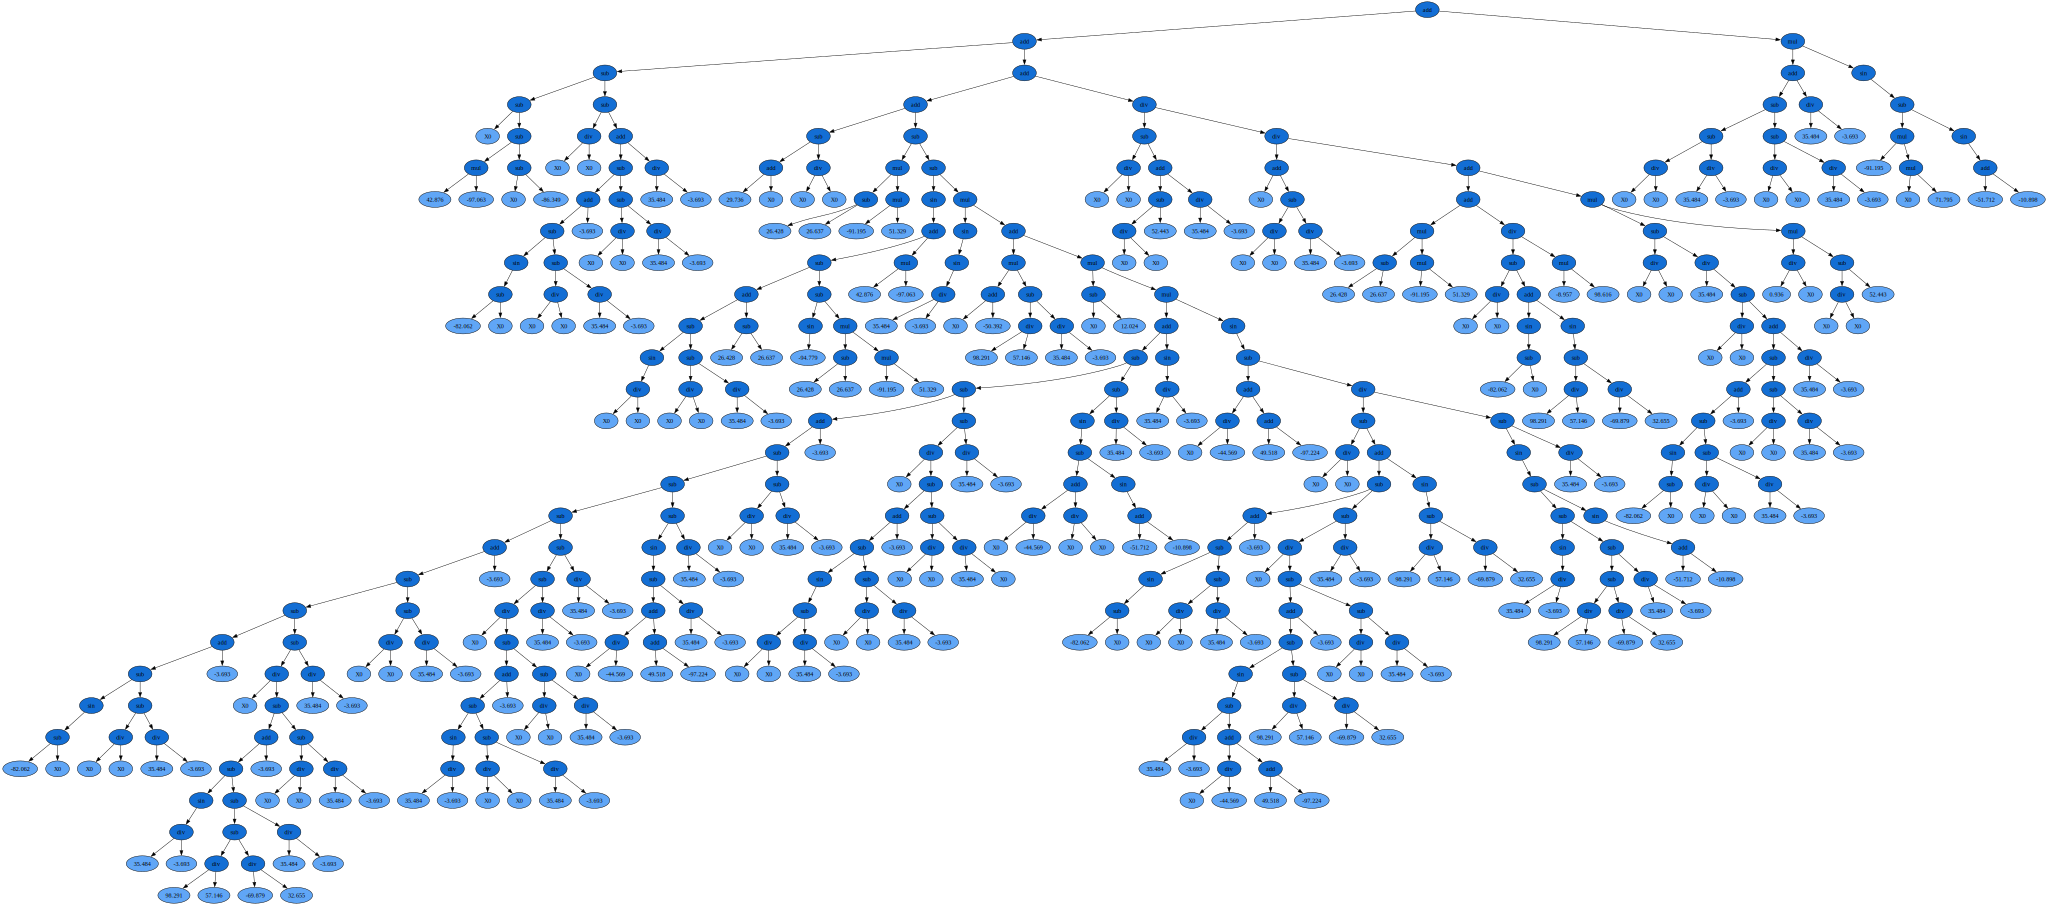

In [ ]:
import graphviz
dot_data = est_gp._program.export_graphviz()
graph = graphviz.Source(dot_data)
graph

In [ ]:
# Предсказания
y_gp = est_gp.predict(np.array(xnum_test).reshape(-1, 1))
y_gp[:10]

array([8286.51589135, 8245.09917452, 8226.13938592, 8197.16481737,
       8174.21022969, 8174.25991616, 8148.25477726, 8099.9877785 ,
       8075.11127306, 8052.58963023])

In [ ]:
# Записываем предсказания в DataFrame
ts_fb2['predictions_GPLEARN'] = (train_size * [np.NAN]) + list(y_gp)

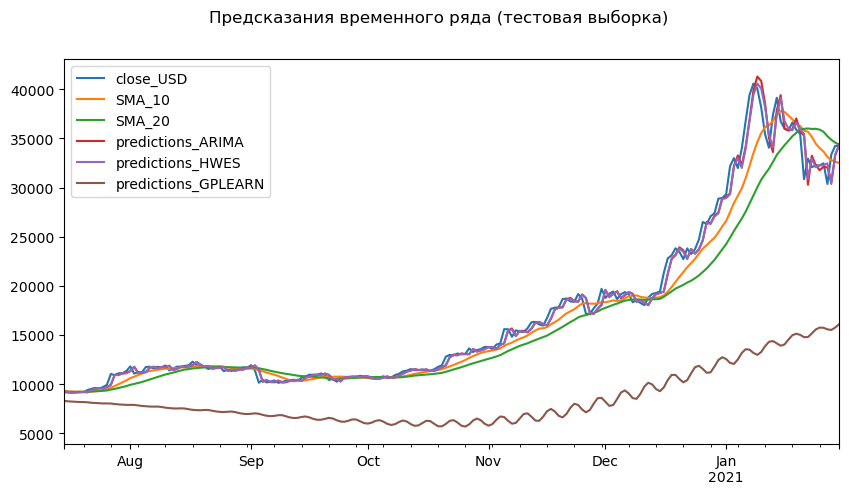

In [ ]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Предсказания временного ряда (тестовая выборка)')
ts_fb2[train_size:].plot(ax=ax, legend=True)
pyplot.show()

## 7. Оценка качества прогнозов

Для сравнения полученных моделей используются следующие метрики:
- **MAE (Mean Absolute Error):** средняя абсолютная ошибка.
- **RMSE (Root Mean Square Error):** среднеквадратичная ошибка.
- **MAPE (Mean Absolute Percentage Error):** средняя абсолютная процентная ошибка.
- **R² (Coefficient of Determination):** коэффициент детерминации.

Метрики рассчитываются на тестовой выборке. Это позволяет объективно сравнить, какая из моделей лучше справляется с прогнозированием.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Функция для расчета всех метрик
def calculate_metrics(actual, predicted, model_name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    r2 = r2_score(actual, predicted)
    
    print(f"\n{model_name}:")
    print(f"  MAE:  {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  R²:   {r2:.4f}")
    
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

# Расчет метрик для каждой модели
# ARIMA
results_arima = calculate_metrics(test, predictions_arima, "ARIMA")

# Exponential Smoothing
results_es = calculate_metrics(test, predictions_es, "Exponential Smoothing")

# GPlearn (если есть predictions_gp)
if 'predictions_gp' in locals():
    results_gp = calculate_metrics(test, predictions_gp, "GPlearn")



ARIMA:
  MAE:  497.24
  RMSE: 873.93
  MAPE: 2.42%
  R²:   0.9896

Exponential Smoothing:
  MAE:  494.87
  RMSE: 860.56
  MAPE: 2.41%
  R²:   0.9900


## 8. Сравнение результатов и общий вывод

В ходе лабораторной работы были построены и протестированы три модели прогнозирования временного ряда:

1.  **ARIMA (6,1,0)** — классический статистический подход.
2.  **Экспоненциальное сглаживание** — еще один статистический метод.
3.  **Символьная регрессия (GPlearn)** — метод машинного обучения, основанный на генетическом программировании.

**Вывод:**
Все модели показали высокое качество прогнозирования (R² > 0.98), что говорит о том, что ряд обладает сильной трендовой составляющей. Наилучшие результаты по метрикам MAE, RMSE и MAPE показала модель **Экспоненциальное сглаживание**, которая немного превзошла ARIMA. Символьная регрессия, хотя и позволила найти аналитическую формулу, уступила статистическим методам в точности.

Таким образом, для данного временного ряда статистические методы (экспоненциальное сглаживание) являются предпочтительными.